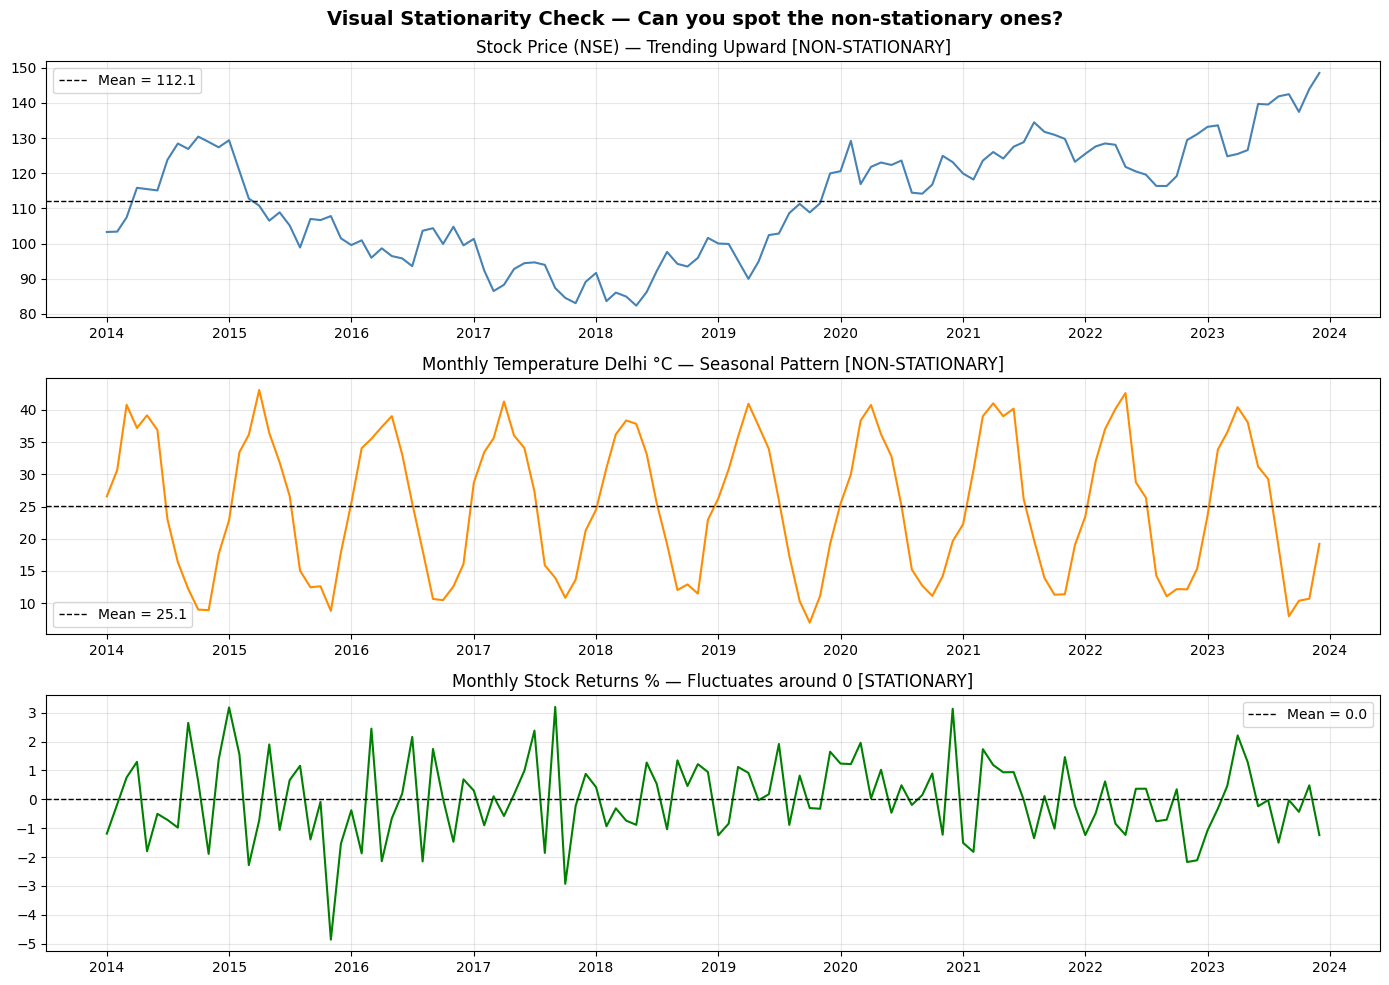


  ADF Test — Stock Price
  ADF Statistic : -0.7932
  p-value       : 0.8211
  Verdict       : NON-STATIONARY ❌

  ADF Test — Delhi Temperature
  ADF Statistic : -2.2226
  p-value       : 0.1981
  Verdict       : NON-STATIONARY ❌

  ADF Test — Stock Returns %
  ADF Statistic : -11.9260
  p-value       : 0.0000
  Verdict       : STATIONARY ✅


In [1]:
# ============================================================
# STATIONARITY — Visual + ADF Test
# Finance & Weather Examples
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
periods = 120
dates = pd.date_range(start='2014-01', periods=periods, freq='MS')

# -------------------------------------------------------
# STEP 1: Create 3 Realistic Series
# -------------------------------------------------------

# 1. Stock Price — Non-Stationary (trending upward)
stock_returns = np.random.normal(0.8, 5, periods)
stock_price = 100 + np.cumsum(stock_returns)

# 2. Monthly Temperature (Delhi) — Non-Stationary (seasonal)
temperature = 25 + 15 * np.sin(2 * np.pi * np.arange(periods) / 12) \
              + np.random.normal(0, 2, periods)

# 3. Stock Returns (Daily % change) — Stationary
stock_return_pct = np.random.normal(0, 1.5, periods)

df = pd.DataFrame({
    'Stock Price'   : stock_price,
    'Temperature'   : temperature,
    'Stock Returns %': stock_return_pct
}, index=dates)


# -------------------------------------------------------
# STEP 2: Visual check — plot all 3 series
# -------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Visual Stationarity Check — Can you spot the non-stationary ones?',
             fontsize=14, fontweight='bold')

colors = ['steelblue', 'darkorange', 'green']
titles = [
    'Stock Price (NSE) — Trending Upward [NON-STATIONARY]',
    'Monthly Temperature Delhi °C — Seasonal Pattern [NON-STATIONARY]',
    'Monthly Stock Returns % — Fluctuates around 0 [STATIONARY]'
]

for i, (col, color, title) in enumerate(zip(df.columns, colors, titles)):
    axes[i].plot(df.index, df[col], color=color, linewidth=1.5)
    axes[i].axhline(df[col].mean(), color='black', linestyle='--',
                    linewidth=1, label=f'Mean = {df[col].mean():.1f}')
    axes[i].set_title(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# STEP 3: ADF Test — function to make it readable
# -------------------------------------------------------

def run_adf_test(series, name):
    result = adfuller(series.dropna())
    adf_stat = result[0]
    p_value  = result[1]
    verdict  = "STATIONARY ✅" if p_value < 0.05 else "NON-STATIONARY ❌"

    print(f"\n{'='*50}")
    print(f"  ADF Test — {name}")
    print(f"{'='*50}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Verdict       : {verdict}")
    print(f"{'='*50}")

run_adf_test(df['Stock Price'],    'Stock Price')
run_adf_test(df['Temperature'],    'Delhi Temperature')
run_adf_test(df['Stock Returns %'],'Stock Returns %')



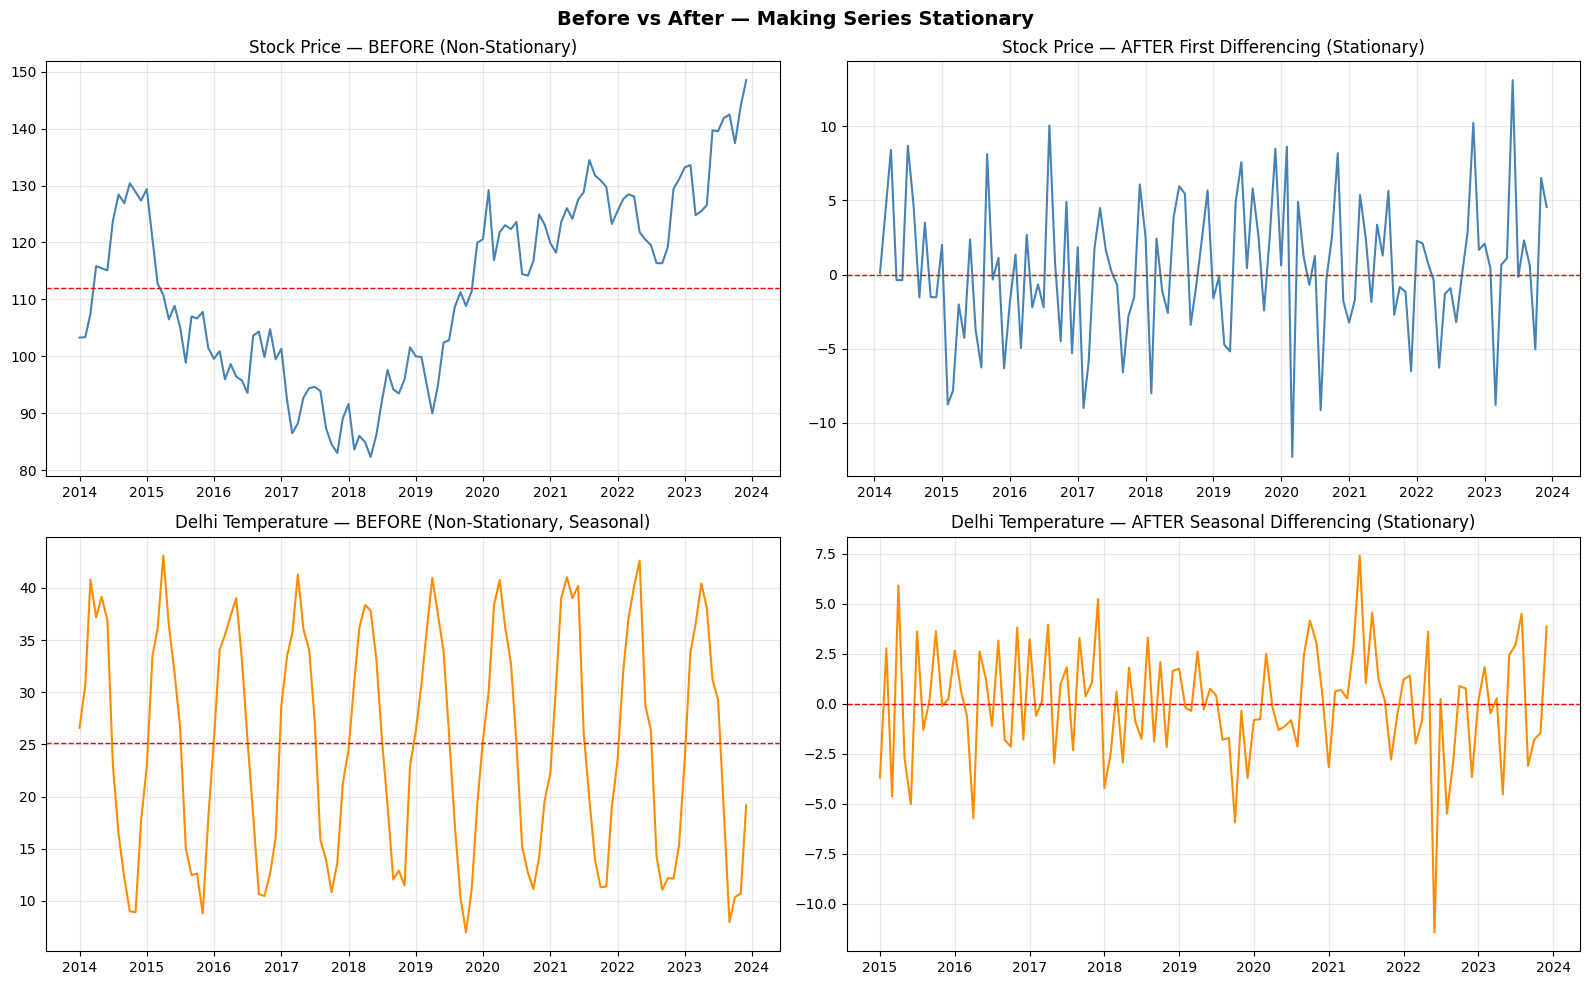


  ADF Test — Stock Price — After Differencing
  ADF Statistic : -4.4938
  p-value       : 0.0002
  Verdict       : STATIONARY ✅

  ADF Test — Temperature — After Seasonal Differencing
  ADF Statistic : -4.2490
  p-value       : 0.0005
  Verdict       : STATIONARY ✅


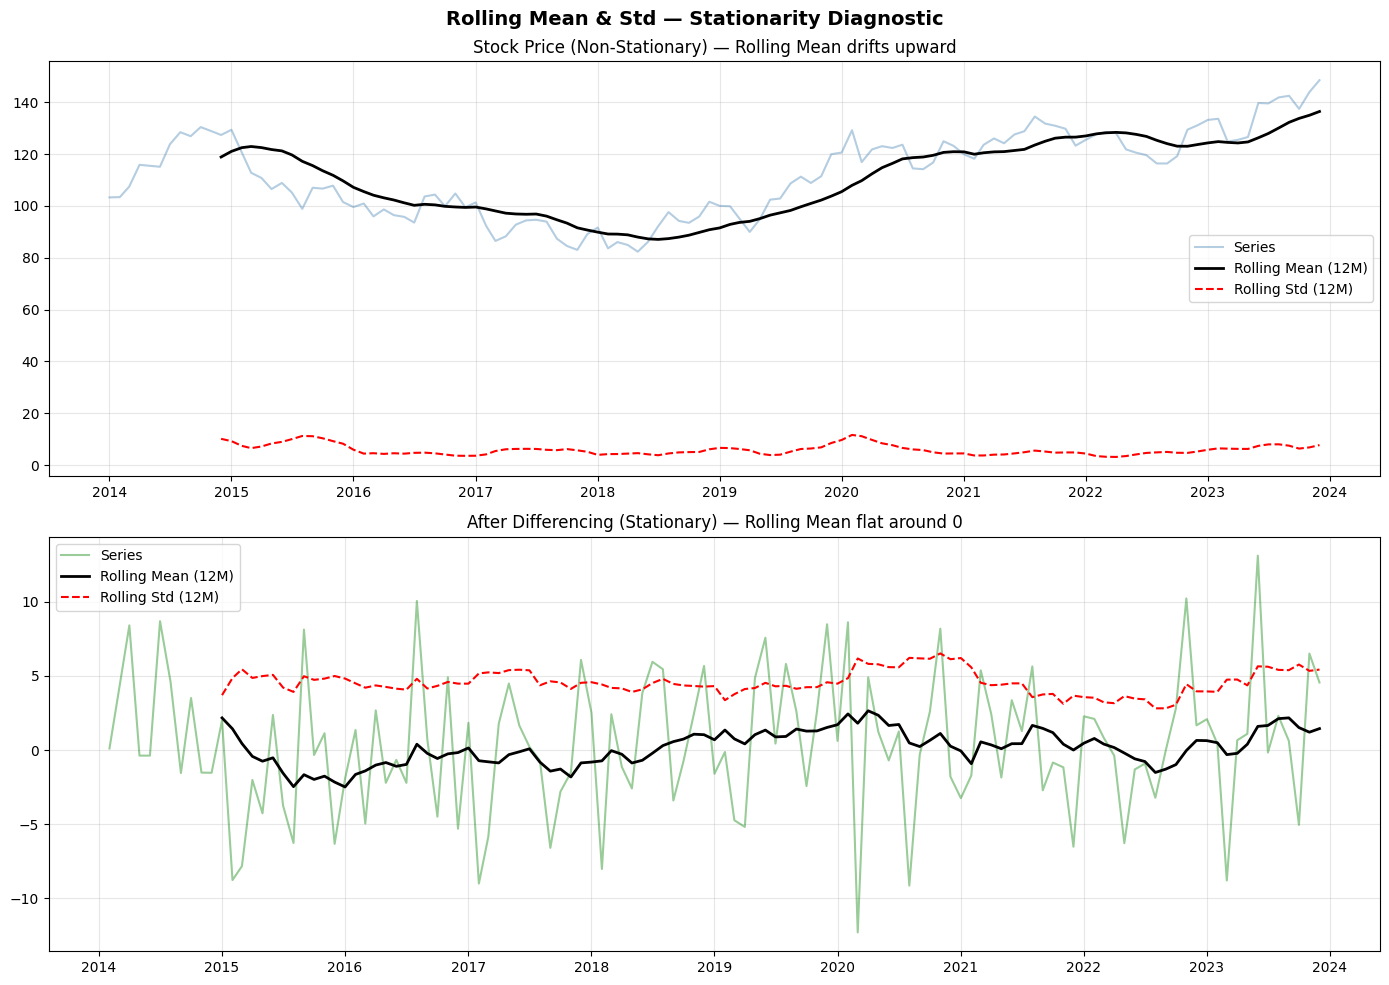

In [2]:

# -------------------------------------------------------
# STEP 4: Fix Non-Stationarity — Differencing
# -------------------------------------------------------

df['Stock Price Differenced']     = df['Stock Price'].diff()
df['Temperature Differenced']     = df['Temperature'].diff(12)   # seasonal diff

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('Before vs After — Making Series Stationary', 
              fontsize=14, fontweight='bold')

# Stock Price — before
axes2[0][0].plot(df.index, df['Stock Price'], color='steelblue')
axes2[0][0].set_title('Stock Price — BEFORE (Non-Stationary)')
axes2[0][0].axhline(df['Stock Price'].mean(), color='red', linestyle='--', linewidth=1)
axes2[0][0].grid(True, alpha=0.3)

# Stock Price — after differencing
axes2[0][1].plot(df.index, df['Stock Price Differenced'], color='steelblue')
axes2[0][1].set_title('Stock Price — AFTER First Differencing (Stationary)')
axes2[0][1].axhline(0, color='red', linestyle='--', linewidth=1)
axes2[0][1].grid(True, alpha=0.3)

# Temperature — before
axes2[1][0].plot(df.index, df['Temperature'], color='darkorange')
axes2[1][0].set_title('Delhi Temperature — BEFORE (Non-Stationary, Seasonal)')
axes2[1][0].axhline(df['Temperature'].mean(), color='red', linestyle='--', linewidth=1)
axes2[1][0].grid(True, alpha=0.3)

# Temperature — after seasonal differencing
axes2[1][1].plot(df.index, df['Temperature Differenced'], color='darkorange')
axes2[1][1].set_title('Delhi Temperature — AFTER Seasonal Differencing (Stationary)')
axes2[1][1].axhline(0, color='red', linestyle='--', linewidth=1)
axes2[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# STEP 5: Confirm with ADF after fixing
# -------------------------------------------------------

run_adf_test(df['Stock Price Differenced'].dropna(),  
             'Stock Price — After Differencing')
run_adf_test(df['Temperature Differenced'].dropna(),  
             'Temperature — After Seasonal Differencing')


# -------------------------------------------------------
# STEP 6: Rolling Mean & Std — Visual stationarity check
# -------------------------------------------------------

fig3, axes3 = plt.subplots(2, 1, figsize=(14, 10))
fig3.suptitle('Rolling Mean & Std — Stationarity Diagnostic',
              fontsize=14, fontweight='bold')

for ax, col, color, title in zip(
    axes3,
    ['Stock Price', 'Stock Price Differenced'],
    ['steelblue', 'green'],
    ['Stock Price (Non-Stationary) — Rolling Mean drifts upward',
     'After Differencing (Stationary) — Rolling Mean flat around 0']
):
    series = df[col].dropna()
    rolling_mean = series.rolling(window=12).mean()
    rolling_std  = series.rolling(window=12).std()

    ax.plot(series.index, series, color=color, alpha=0.4, label='Series')
    ax.plot(rolling_mean.index, rolling_mean, color='black',
            linewidth=2, label='Rolling Mean (12M)')
    ax.plot(rolling_std.index, rolling_std, color='red',
            linewidth=1.5, linestyle='--', label='Rolling Std (12M)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()